In [ ]:
import os
os.chdir("/n/fs/jc-project/khu/sae_clean")

# Using an SAE inside a video model

Run the backbone up to block `LAYER`, take that block's patch tokens, pass them through the layer's SAE (and edit its latents if you like), then resume the remaining blocks from the result:

```python
patches = videomodel.encode(video, layer=LAYER)   # (B, N, D): block LAYER's patch tokens; the forward stops there
latents = sae.encode(patches)                    # (B, N, dict_size), ~20 active per token
recon   = sae.decode(latents)                    # (B, N, D)
output  = videomodel.decode(recon, layer=LAYER)  # blocks LAYER+1 .. end -> (B, D) features
```

`videomodel.encode(video)` without `layer` is the plain full forward; `videomodel.decode(patches, layer=LAYER)` on *unmodified* patches reproduces it exactly.

These two calls are the whole interface: the SAE is never attached to the model, and `scripts/evaluate.py --layer L` runs exactly these four lines on every batch.

(The first cell moves to the repo root, which the imports and relative paths assume; change it to wherever `sae_clean` lives.)

In [ ]:
import torch
from data import load_split, read_clip
from models import get_model
from saes import list_saes, load_sae

MODEL_ID = "vivit-b-16x2-kinetics400"   # any config/<model_id>.yaml
LAYER = 6
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

print("layers with an SAE:", list_saes()[MODEL_ID])

## Load the model and the layer's SAE

`get_model` loads the checkpoint + revision named in `config/<MODEL_ID>.yaml` (and checks its shape); `load_sae` loads the SAE from that config's `sae.dir` and checks it was fitted on this backbone.

In [3]:
videomodel = get_model(MODEL_ID, device=DEVICE)
sae = load_sae(MODEL_ID, LAYER, device=DEVICE, backbone=videomodel)

print(f"{MODEL_ID}: {videomodel.num_layers} blocks, {videomodel.num_frames} frames, "
      f"patch grid {videomodel.grid_shape}, width {videomodel.hidden_dim}")
print(f"SAE at block {LAYER}: {sae.activation_dim} -> {sae.dict_size} latents, k = {int(sae.k)}")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

vivit-b-16x2-kinetics400: 12 blocks, 32 frames, patch grid (16, 14, 14), width 768
SAE at block 6: 768 -> 12288 latents, k = 20


## A clip

`examples/video/` holds one Kinetics-400 val clip as JPEG frames (300 frames, 10 s at 30 fps, 270x360; *getting a haircut*, `vaFYLmIqNQ0_000034_000044`), so this runs without the dataset. `read_clip` takes a frame directory or a video file and picks the model's number of frames evenly across the clip; `preprocess` runs the model's own processor.

In [ ]:
import numpy as np
from PIL import Image

classes = load_split("datafile/kinetics400.json", "val")["classes"]   # the 400 Kinetics-400 class names
label = classes.index("getting a haircut")                            # what the example clip shows

frames = read_clip("examples/video", videomodel.num_frames)   # (T, H, W, 3) uint8
video = videomodel.preprocess(frames)                          # pixel_values, batch of 1

print("examples/video ->", classes[label])
print("frames", frames.shape, "-> pixel_values", tuple(video.shape))

# Video visualization
display(Image.fromarray(frames[0]))

## Split forward through the SAE

In [5]:
patches = videomodel.encode(video, layer=LAYER)   # (1, N, D): block LAYER's patch tokens
latents = sae.encode(patches)                    # (1, N, dict_size)
recon = sae.decode(latents)                      # (1, N, D)
output = videomodel.decode(recon, layer=LAYER)   # (1, D): the rest of the model on the reconstruction

print("patches", tuple(patches.shape), " latents", tuple(latents.shape), " output", tuple(output.shape))

patches (1, 3136, 768)  latents (1, 3136, 12288)  output (1, 768)


How good is the reconstruction, and how far does it move the model's output? The last line checks that resuming from the *unmodified* patches gives exactly the full forward.

In [6]:
clean = videomodel.encode(video)                  # the full forward, no SAE

x, r = patches[0], recon[0]
fve = 1 - ((x - r) ** 2).sum() / ((x - x.mean(0)) ** 2).sum()
l0 = (latents[0] > 0).sum(-1).float()
print(f"reconstruction: FVE {fve:.3f}   L0 per token: mean {l0.mean():.1f}")
print(f"output, clean vs through the SAE: cosine {torch.nn.functional.cosine_similarity(clean, output).item():.4f}")
print("resume from unmodified patches == full forward:",
      torch.equal(videomodel.decode(patches, layer=LAYER), clean))

reconstruction: FVE 0.980   L0 per token: mean 17.2
output, clean vs through the SAE: cosine 0.8996
resume from unmodified patches == full forward: True


### Latent Visualization

latent 439: fires on 10.4% of patches, max activation 11.27


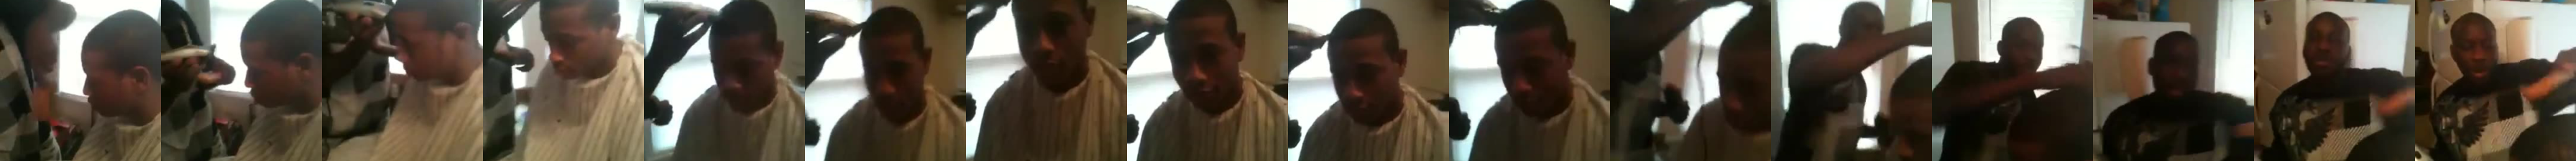

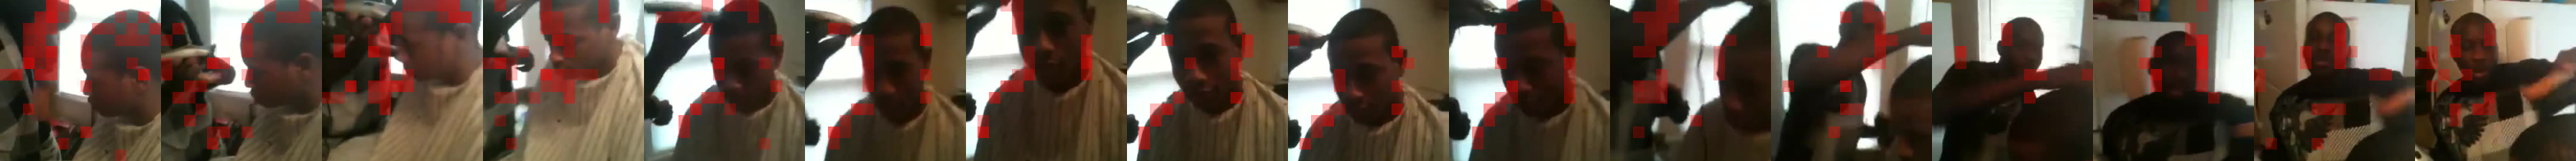

In [8]:
LATENT = 439                                              # the latent to show (any index < sae.dict_size)

t, h, w = videomodel.grid_shape
lat = latents[0].detach().reshape(t, h, w, -1)[..., LATENT].float().cpu()   # (T', H', W'): its activation per patch
vmax = max(float(lat.max()), 1e-6)
print(f"latent {LATENT}: fires on {(lat > 0).float().mean():.1%} of patches, max activation {lat.max():.2f}")

# What the model saw: pixel_values after its own resize/crop (so the patch grid lines up), as uint8 RGB.
view = video[0].float().cpu()
if view.dim() == 3:                                       # SigLIP: a single (3, H, W) image
    view = view[None]
if view.shape[-1] != 3:                                   # (T, 3, H, W) -> (T, H, W, 3)
    view = view.permute(0, 2, 3, 1)
view = ((view - view.amin()) / (view.amax() - view.amin()) * 255).round().byte().numpy()
steps = [view[int((ti + 0.5) * len(view) / t)] for ti in range(t)]   # one frame per time step


def strip(images):
    """Images side by side in one row."""
    return Image.fromarray(np.concatenate(images, axis=1))


def overlay(img, act):
    """Red over the patches where the latent fires, stronger where it fires harder."""
    heat = Image.fromarray((act / vmax * 255).clamp(0, 255).byte().numpy())
    heat = heat.resize((img.shape[1], img.shape[0]), Image.NEAREST)      # one block per patch
    alpha = np.asarray(heat, dtype=np.float32)[..., None] / 255 * 0.7
    return (img * (1 - alpha) + np.array([255, 0, 0]) * alpha).astype(np.uint8)


display(strip(steps))                                                  # the frames, one per time step
display(strip([overlay(img, lat[ti]) for ti, img in enumerate(steps)]))   # where LATENT fires

## What a latent responds to

One clip shows *where* a latent fires, not what it stands for. `scripts/top_activations.py` scores every clip of a clip list by each latent's max activation over the clip's patches and keeps, per latent, its top clips and its mean score per class:

```bash
python scripts/top_activations.py --model vivit-b-16x2-kinetics400 --layer 6   # -> results/<model_id>/top_activations/l<layer>.pt
```

The cells below read that file for the `MODEL_ID` and `LAYER` above.

In [ ]:
from pathlib import Path

TOP = Path("results") / MODEL_ID / "top_activations" / f"l{LAYER}.pt"   # what scripts/top_activations.py wrote
top = torch.load(TOP)
assert top["sae"]["sha256"] == sae.config["sha256"], f"{TOP} was computed with another SAE"

# The latents most tied to one class: the share of a latent's (class-mean) activation held by its
# top class, among the latents that fire on at least 5 clips.
share, cls = (top["class_mean"] / top["class_mean"].sum(1, keepdim=True).clamp(min=1e-9)).max(1)
share[top["clip_freq"] * top["n_clips"] < 5] = 0
print(f"{top['n_clips']:,} clips of {top['clips']['file']}:{top['clips']['split']}")
for i in share.argsort(descending=True)[:20].tolist():
    print(f"latent {i:>5}: {share[i]:4.0%} {top['classes'][cls[i]]:<30} fires on {top['clip_freq'][i]:.2%} of clips")

In [ ]:
from data import ClipList

LATENT = int(share.argmax())                              # the latent to show (any index < sae.dict_size)

mean = top["class_mean"][LATENT]
print(f"latent {LATENT}: fires on {top['clip_freq'][LATENT]:.2%} of clips; its classes, by mean activation:")
for c in mean.argsort(descending=True)[:5].tolist():
    print(f"  {mean[c]:6.2f}  {top['classes'][c]}")


def seen(pixel_values):
    """What the model saw, one uint8 RGB frame per time step (as in Latent Visualization above)."""
    view = pixel_values[0].float().cpu()
    if view.dim() == 3:
        view = view[None]
    if view.shape[-1] != 3:
        view = view.permute(0, 2, 3, 1)
    view = ((view - view.amin()) / (view.amax() - view.amin()) * 255).round().byte().numpy()
    return [view[int((ti + 0.5) * len(view) / t)] for ti in range(t)]


# Its top clips, best first, with the latent's activation over each (one colour scale for all of them).
clips = ClipList(top["data_root"], [], videomodel.num_frames, top["clips"]["short_side"])
vmax = max(float(top["top_val"][LATENT, 0]), 1e-6)
for score, i in zip(top["top_val"][LATENT].tolist(), top["top_clip"][LATENT].tolist()):
    if i < 0:                                             # fewer clips fired than were kept
        break
    px = videomodel.preprocess(clips.load(top["keys"][i]))
    act = sae.encode(videomodel.encode(px, layer=LAYER))[0].detach().reshape(t, h, w, -1)[..., LATENT].float().cpu()
    print(f"{score:.2f}  {top['keys'][i]}")
    display(strip([overlay(img, act[ti]) for ti, img in enumerate(seen(px))]))